<a href="https://colab.research.google.com/github/Samriddha03/Diabetes_Detection_System/blob/main/Fake_News_XAI_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers==4.40.2 datasets accelerate
!pip uninstall -y transformers datasets tokenizers accelerate
!pip install transformers datasets accelerate scikit-learn
!pip install numpy==1.26.4 pandas==2.2.2 pyarrow==21.0.0 --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 60.8 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.7.1
    Uninstalling huggingface_hub-1.7.1:
      Successfully uninstalled huggingface_hub-1.7.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the follow

In [ ]:
!pip install transformers datasets accelerate scikit-learn


In [ ]:
!pip install numpy==1.26.4 pandas==2.2.2 pyarrow==21.0.0 --force-reinstall

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached pandas-2.2.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (19 kB)
  Using cached pyarrow-21.0.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (3.3 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached pytz-2026.1.post1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
Using cached pandas-2.2.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.7 MB)
Using cached pyarrow-21.0.0-cp312-cp312-manylinux_2_28_x86_64.whl (42.8 MB)
Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
Using cached pytz-2026.1.post1-py2.py3-none-any.whl (510 kB)
Using cached tzdata-20

In [ ]:
import numpy as np
import pandas as pd
import pyarrow as pa

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("PyArrow:", pa.__version__)

NumPy: 1.26.4
Pandas: 2.2.2
PyArrow: 21.0.0


In [ ]:
from google.colab import drive
import zipfile
import os

# Mount Google Drive
drive.mount('/content/drive')

# Extract Dataset
zip_path = '/content/drive/MyDrive/archive (3).zip'
extract_path = '/content/drive/MyDrive/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete!")
os.listdir('/content/drive/MyDrive')

Mounted at /content/drive
Extraction complete!


['Classroom',
 'Brownspot',
 'Notes_250628_014702.txt',
 'Notes_250425_215920.txt',
 'Notes_250308_190435.txt',
 'Notes_250628_014639.txt',
 'Notes_250709_015412.txt',
 'Screenshot_20251014_135159_Samsung Internet.jpg',
 'Colab Notebooks',
 'fraud_model_1feature.pkl',
 'Samriddha Chakraborty.pdf',
 'DOC-20260226-WA0016..pdf',
 'My resume',
 'archive (3).zip',
 'Fake.csv',
 'True.csv',
 'my_trained_model',
 'fake_news_bert_model',
 'cleaned_fake_news.csv']

In [ ]:
# Load datasets
fake_df = pd.read_csv('/content/drive/MyDrive/Fake.csv')
true_df = pd.read_csv('/content/drive/MyDrive/True.csv')


In [ ]:
fake_df['label'] = 0   # Fake news
true_df['label'] = 1   # Real news

In [ ]:
df = pd.concat([fake_df, true_df], axis=0)

In [ ]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
# Check for duplicates
print("Duplicate articles:", df.duplicated(subset="text").sum())

Duplicate articles: 6252


In [ ]:
# Remove duplicates
df = df.drop_duplicates(subset="text")

In [ ]:
print("Combined shape:", df.shape)
df.head()

# Save cleaned dataset
df.to_csv('/content/drive/MyDrive/cleaned_fake_news.csv', index=False)

# Check class distribution
print(df['label'].value_counts())

Combined shape: (38646, 5)
label
1    21191
0    17455
Name: count, dtype: int64


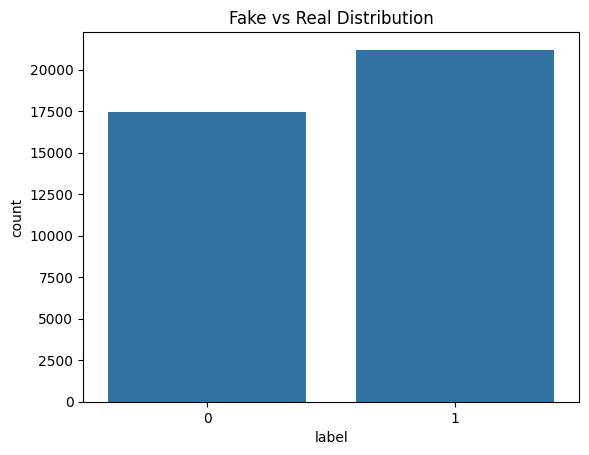

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution plot
sns.countplot(x="label", data=df)
plt.title("Fake vs Real Distribution")
plt.show()

In [ ]:
# Text length analysis
df["text_length"] = df["text"].apply(lambda x: len(str(x).split()))
print(df["text_length"].describe())

count    38646.000000
mean       403.089971
std        313.828131
min          0.000000
25%        216.000000
50%        369.000000
75%        511.000000
max       8135.000000
Name: text_length, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 30916
Test size: 7730


In [ ]:
from datasets import Dataset
from transformers import BertTokenizerFast
import torch

# Convert to Hugging Face Dataset
train_df = pd.DataFrame({
    "text": X_train,
    "label": y_train
})

val_df = pd.DataFrame({
    "text": X_test,
    "label": y_test
})

train_dataset = Dataset.from_pandas(train_df)
eval_dataset = Dataset.from_pandas(val_df)


In [ ]:
# Load tokenizer
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
# Tokenize
def tokenize_fn(batch):
    return tokenizer(batch['text'], padding='max_length', truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize_fn, batched=True)
eval_dataset = eval_dataset.map(tokenize_fn, batched=True)

# Set columns for Trainer
train_dataset = train_dataset.rename_column("label", "labels")
eval_dataset = eval_dataset.rename_column("label", "labels")
train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
eval_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])



Map:   0%|          | 0/30916 [00:00<?, ? examples/s]

Map:   0%|          | 0/7730 [00:00<?, ? examples/s]

In [ ]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
import transformers
print(transformers.__version__)

5.3.0


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    logging_steps=200,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none"
)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    return {"accuracy": acc, "f1": f1}

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.000023,0.003758,0.999612,0.999612
2,0.006502,0.008257,0.999224,0.999224
3,0.000008,0.006062,0.999353,0.999353


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=11595, training_loss=0.0052175381448637545, metrics={'train_runtime': 2566.2305, 'train_samples_per_second': 36.142, 'train_steps_per_second': 4.518, 'total_flos': 6100756040632320.0, 'train_loss': 0.0052175381448637545, 'epoch': 3.0})

In [ ]:
predictions = trainer.predict(eval_dataset)
print(predictions.metrics)

{'test_loss': 0.0038154234644025564, 'test_accuracy': 0.9996119016817594, 'test_f1': 0.999611906579301, 'test_runtime': 58.5537, 'test_samples_per_second': 132.016, 'test_steps_per_second': 16.515}


In [ ]:
trainer.save_model("/content/drive/MyDrive/fake_news_bert_model")
tokenizer.save_pretrained("/content/drive/MyDrive/fake_news_bert_model")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/fake_news_bert_model/tokenizer_config.json',
 '/content/drive/MyDrive/fake_news_bert_model/tokenizer.json')

In [ ]:
from transformers import pipeline
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Load the trained model
nlp = pipeline(
    "text-classification",
    model="/content/drive/MyDrive/fake_news_bert_model",
    tokenizer="/content/drive/MyDrive/fake_news_bert_model",
    device=0
)

# Example texts
texts = [
    "Breaking: Government announces new policy today.",
    "You won $1,000,000! Click here to claim your prize!",
    "Scientists discovered a new planet in the solar system."
]

# Run prediction
results = nlp(texts)

# Convert labels to readable names
label_map = {
    "LABEL_0": "Fake",
    "LABEL_1": "Real"
}

formatted_results = []
for text, res in zip(texts, results):
    formatted_results.append({
        "text": text,
        "label": label_map.get(res["label"], res["label"]),
        "confidence": res["score"]
    })

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
# Print results
for r in formatted_results:
    print(r)

print(model.config.id2label)

label_map = {
    "LABEL_0": "Fake",
    "LABEL_1": "Real"
}
predictions = trainer.predict(eval_dataset)
print(predictions.metrics)

{'text': 'Breaking: Government announces new policy today.', 'label': 'Fake', 'confidence': 0.9999734163284302}
{'text': 'You won $1,000,000! Click here to claim your prize!', 'label': 'Fake', 'confidence': 0.9999735355377197}
{'text': 'Scientists discovered a new planet in the solar system.', 'label': 'Fake', 'confidence': 0.9999717473983765}
{0: 'LABEL_0', 1: 'LABEL_1'}


{'test_loss': 0.0038154234644025564, 'test_accuracy': 0.9996119016817594, 'test_f1': 0.999611906579301, 'test_runtime': 58.7318, 'test_samples_per_second': 131.615, 'test_steps_per_second': 16.465}


In [ ]:
# install XAI libraries
!pip install lime shap --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 11.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 97.1 MB/s eta 0:00:00


In [ ]:
from transformers import pipeline
from lime.lime_text import LimeTextExplainer
import numpy as np
from IPython.display import display, HTML

# Load your trained model
classifier = pipeline(
    "text-classification",
    model="/content/drive/MyDrive/fake_news_bert_model",
    tokenizer="/content/drive/MyDrive/fake_news_bert_model"
)

class_names = ["Fake", "Real"]

explainer = LimeTextExplainer(class_names=class_names)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
def predictor(texts):
    outputs = classifier(texts)
    probs = []

    for o in outputs:
        if o['label'] == 'LABEL_0':
            probs.append([o['score'], 1-o['score']])
        else:
            probs.append([1-o['score'], o['score']])

    return np.array(probs)

text = "Government secretly controls media reports."

exp = explainer.explain_instance(
    text,
    predictor,
    num_features=10,
    num_samples=200
)

display(HTML(exp.as_html()))

In [ ]:
exp

In [ ]:
from IPython.display import display
display(exp.as_html())


'<html>\n        <meta http-equiv="content-type" content="text/html; charset=UTF8">\n        <head><script>var lime =\n/******/ (function(modules) { // webpackBootstrap\n/******/ \t// The module cache\n/******/ \tvar installedModules = {};\n/******/\n/******/ \t// The require function\n/******/ \tfunction __webpack_require__(moduleId) {\n/******/\n/******/ \t\t// Check if module is in cache\n/******/ \t\tif(installedModules[moduleId])\n/******/ \t\t\treturn installedModules[moduleId].exports;\n/******/\n/******/ \t\t// Create a new module (and put it into the cache)\n/******/ \t\tvar module = installedModules[moduleId] = {\n/******/ \t\t\texports: {},\n/******/ \t\t\tid: moduleId,\n/******/ \t\t\tloaded: false\n/******/ \t\t};\n/******/\n/******/ \t\t// Execute the module function\n/******/ \t\tmodules[moduleId].call(module.exports, module, module.exports, __webpack_require__);\n/******/\n/******/ \t\t// Flag the module as loaded\n/******/ \t\tmodule.loaded = true;\n/******/\n/******/ 

In [ ]:
exp.as_list()

[('media', -9.437443872978329e-07),
 ('secretly', -6.013425389068785e-07),
 ('Government', -4.540996833212501e-07),
 ('reports', -1.859510385217926e-07),
 ('controls', -1.0105254581746738e-08)]

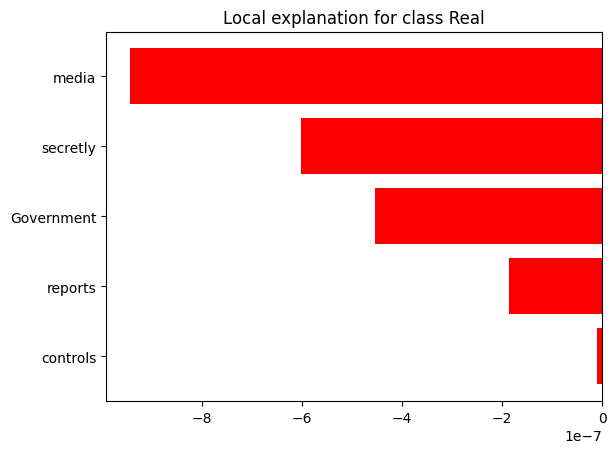

In [ ]:
import matplotlib.pyplot as plt

fig = exp.as_pyplot_figure()
plt.show()

In [ ]:
import shap
shap.initjs()

In [ ]:
# Load your model
classifier = pipeline(
    "text-classification",
    model="/content/drive/MyDrive/fake_news_bert_model",
    tokenizer="/content/drive/MyDrive/fake_news_bert_model"
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
# Create SHAP explainer
explainer = shap.Explainer(classifier)

def explain_text(sentence):
    shap_values = explainer([sentence])
    shap.plots.text(shap_values[0])

explain_text("Shocking secret report claims government hiding cure for major disease")

explain_text("Government releases official report showing steady economic growth this year")

explain_text("Scientists announce new research findings on climate change trends")


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [ ]:
# install BERTVIZ
!pip install bertviz --quiet

from bertviz import head_view
from transformers import BertTokenizer, BertModel

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model_att = BertModel.from_pretrained("bert-base-uncased", output_attentions=True)

sentence = "Government secretly controls media reports."

inputs = tokenizer(sentence, return_tensors="pt")

outputs = model_att(**inputs)

attention = outputs.attentions
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

head_view(attention, tokens)

texts = [
    "Breaking news: Government passes new law",
    "Secret cure discovered by scientists"
]

results = classifier(texts)

for t,r in zip(texts,results):
    print(t)
    print(r)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 111.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 91.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 11.4 MB/s eta 0:00:00


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


<IPython.core.display.Javascript object>

Breaking news: Government passes new law
{'label': 'LABEL_0', 'score': 0.9999734163284302}
Secret cure discovered by scientists
{'label': 'LABEL_0', 'score': 0.9999721050262451}


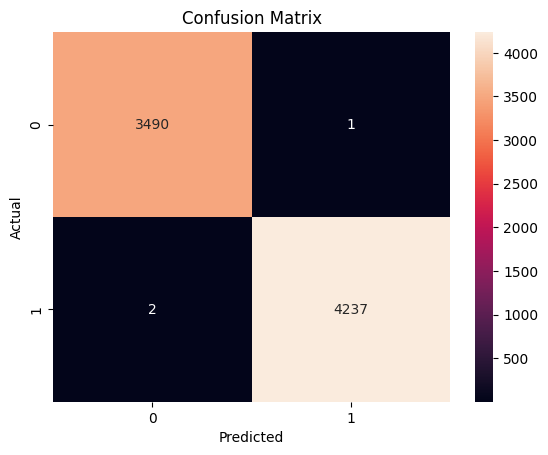

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

preds = trainer.predict(eval_dataset)
y_pred = preds.predictions.argmax(axis=1)
y_true = preds.label_ids

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
texts = [
    "Government announces new economic policy",
    "Secret alien technology hidden by NASA",
    "Scientists publish new climate change research",
    "Miracle cure discovered that heals all diseases"
]

results = classifier(texts)

for t, r in zip(texts, results):
    print(t, "->", r)

print(model.config.id2label)
print(model.config.label2id)

Government announces new economic policy -> {'label': 'LABEL_0', 'score': 0.999971866607666}
Secret alien technology hidden by NASA -> {'label': 'LABEL_0', 'score': 0.9999728202819824}
Scientists publish new climate change research -> {'label': 'LABEL_0', 'score': 0.9999719858169556}
Miracle cure discovered that heals all diseases -> {'label': 'LABEL_0', 'score': 0.9999730587005615}
{0: 'LABEL_0', 1: 'LABEL_1'}
{'LABEL_0': 0, 'LABEL_1': 1}


In [ ]:
import numpy as np

preds = trainer.predict(eval_dataset).predictions
pred_labels = np.argmax(preds, axis=1)

print(np.unique(pred_labels, return_counts=True))

texts = [
"The United States government announced a new economic policy today aimed at boosting infrastructure spending and supporting economic growth across several sectors.",

"Scientists from NASA have published a new study showing climate change is accelerating ice melting in polar regions according to recent satellite data.",

"A secret organization has discovered alien technology hidden deep underground which could allow humans to travel faster than light.",

"A miracle cure has been found that can instantly heal every disease according to a shocking new report circulating online."
]

results = classifier(texts)

for t,r in zip(texts,results):
    print("\nTEXT:",t)
    print(r)


(array([0, 1]), array([3492, 4238]))

TEXT: The United States government announced a new economic policy today aimed at boosting infrastructure spending and supporting economic growth across several sectors.
{'label': 'LABEL_0', 'score': 0.9999737739562988}

TEXT: Scientists from NASA have published a new study showing climate change is accelerating ice melting in polar regions according to recent satellite data.
{'label': 'LABEL_0', 'score': 0.9999735355377197}

TEXT: A secret organization has discovered alien technology hidden deep underground which could allow humans to travel faster than light.
{'label': 'LABEL_0', 'score': 0.9999743700027466}

TEXT: A miracle cure has been found that can instantly heal every disease according to a shocking new report circulating online.
{'label': 'LABEL_0', 'score': 0.9999747276306152}


In [ ]:
texts = [
"WASHINGTON (Reuters) - The United States government announced a new economic policy aimed at boosting infrastructure spending.",

"NEW YORK (Reuters) - Scientists published a new study showing climate change is accelerating ice melting.",

"A secret alien technology hidden underground allows humans to travel faster than light.",

"A miracle cure discovered that heals all diseases instantly according to an online report."
]

results = classifier(texts)

for t,r in zip(texts,results):
    print("\nTEXT:",t)
    print(r)



TEXT: WASHINGTON (Reuters) - The United States government announced a new economic policy aimed at boosting infrastructure spending.
{'label': 'LABEL_1', 'score': 0.9999946355819702}

TEXT: NEW YORK (Reuters) - Scientists published a new study showing climate change is accelerating ice melting.
{'label': 'LABEL_1', 'score': 0.9999947547912598}

TEXT: A secret alien technology hidden underground allows humans to travel faster than light.
{'label': 'LABEL_0', 'score': 0.9999740123748779}

TEXT: A miracle cure discovered that heals all diseases instantly according to an online report.
{'label': 'LABEL_0', 'score': 0.999974250793457}


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
texts = ["Breaking: Scientists confirm Earth is flat in shocking report."]

results = classifier(texts)

for t,r in zip(texts,results):
    print("\nTEXT:",t)
    print(r)



TEXT: Breaking: Scientists confirm Earth is flat in shocking report.
{'label': 'LABEL_0', 'score': 0.9999735355377197}


In [ ]:
import numpy as np
from scipy.special import softmax

# raw logits from trainer
logits = predictions.predictions

# convert logits → probabilities
probs = softmax(logits, axis=1)

# confidence = highest probability per sample
confidence = np.max(probs, axis=1)

print("Average confidence:", np.mean(confidence))
print("Min confidence:", np.min(confidence))
print("Max confidence:", np.max(confidence))


Average confidence: 0.999986
Min confidence: 0.99973077
Max confidence: 0.9999949


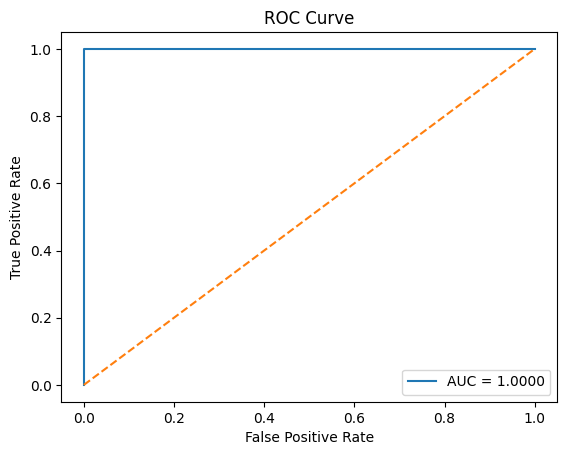

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_true, probs[:,1])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %0.4f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()